# 03 - Modeling dengan Preprocessing

Notebook ini berisi tahap modeling dengan preprocessing pada proyek prediksi churn pelanggan.

Pada tahap sebelumnya, model dibuat menggunakan pendekatan direct modeling sebagai baseline awal. Pada tahap ini, data diproses terlebih dahulu agar lebih siap digunakan oleh model machine learning.

Tahapan utama pada notebook ini meliputi:
- train-test split sebelum preprocessing,
- feature engineering dari kolom tanggal,
- penghapusan fitur yang kurang relevan,
- handling missing value,
- handling outlier,
- encoding fitur kategorikal,
- scaling fitur numerik,
- training tiga model machine learning,
- evaluasi performa model.

## Import Library

Library yang digunakan mencakup library untuk pengolahan data, visualisasi, preprocessing, modeling, evaluasi, serta penyimpanan pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

## Setup Path Project

Path project disiapkan agar dataset, output visualisasi, laporan evaluasi, data processed, dan model dapat disimpan pada folder yang sesuai.

In [2]:
# Mengatur folder utama project
PROJECT_DIR = Path.cwd()

# Jika notebook dijalankan dari folder notebooks, arahkan ke folder utama project
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

# Path dataset dan folder output
DATA_PATH = PROJECT_DIR / "data" / "raw" / "Sales - Marketing customer dataset.csv"

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"
MODELS_DIR = PROJECT_DIR / "models"

# Membuat folder jika belum tersedia
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

WindowsPath('c:/Users/cahya/Project/UAS-BENGKOD-Churn-Prediction/data/raw/Sales - Marketing customer dataset.csv')

## Load Dataset

Dataset dibaca dari folder `data/raw`. Setelah itu dilakukan pengecekan awal untuk memastikan data berhasil dimuat.

In [3]:
# Membaca dataset
df = pd.read_csv(DATA_PATH)

# Menampilkan 5 baris pertama
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [4]:
# Melihat ukuran dataset
df.shape

(15000, 30)

In [5]:
# Melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

## Pengecekan Data Duplikat

Pengecekan duplikasi dilakukan sebelum pemodelan. Jika terdapat data duplikat, data tersebut dihapus agar tidak mengganggu proses training dan evaluasi.

In [6]:
# Mengecek jumlah data duplikat
duplicate_count = df.duplicated().sum()

print("Jumlah data duplikat sebelum handling:", duplicate_count)

# Menghapus duplikasi jika ada
df = df.drop_duplicates().reset_index(drop=True)

print("Jumlah data setelah handling duplikasi:", df.shape[0])

Jumlah data duplikat sebelum handling: 0
Jumlah data setelah handling duplikasi: 15000


## Menentukan Fitur dan Target

Kolom `churn` digunakan sebagai target prediksi. Seluruh kolom lain digunakan sebagai fitur awal sebelum dilakukan seleksi dan preprocessing.

In [7]:
# Menentukan target dan fitur
y = df["churn"]
X = df.drop(columns=["churn"])

print("Jumlah data:", X.shape[0])
print("Jumlah fitur awal:", X.shape[1])
print("\nDistribusi target:")
print(y.value_counts())

Jumlah data: 15000
Jumlah fitur awal: 29

Distribusi target:
churn
0    12702
1     2298
Name: count, dtype: int64


## Train-Test Split

Data dibagi menjadi data latih dan data uji sebelum preprocessing. Hal ini dilakukan agar proses imputasi, encoding, scaling, dan handling outlier tidak menggunakan informasi dari data uji.

Pembagian data menggunakan proporsi 80:20 dan `stratify=y` agar distribusi kelas target tetap seimbang.

In [8]:
# Membagi data menjadi data latih dan data uji
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train_raw:", X_train_raw.shape)
print("X_test_raw:", X_test_raw.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train_raw: (12000, 29)
X_test_raw: (3000, 29)
y_train: (12000,)
y_test: (3000,)


## Feature Engineering dari Kolom Tanggal

Kolom `signup_date` dan `last_purchase_date` tidak langsung digunakan dalam bentuk tanggal mentah. Kolom tersebut diubah menjadi fitur numerik yang lebih mudah dipahami oleh model, seperti:

- `customer_tenure_days`: selisih hari antara tanggal transaksi terakhir dan tanggal pendaftaran.
- `days_since_last_purchase`: jarak hari dari transaksi terakhir terhadap reference date.
- `signup_month`: bulan saat pelanggan mendaftar.
- `last_purchase_month`: bulan transaksi terakhir.

Selain itu, kolom `coupon_code` diubah menjadi fitur `has_coupon_code` untuk menunjukkan apakah pelanggan menggunakan kode kupon atau tidak.

In [9]:
# Reference date diambil dari data latih agar tidak bergantung pada informasi data uji
reference_date = pd.to_datetime(X_train_raw["last_purchase_date"], errors="coerce").max()

reference_date

Timestamp('2025-03-10 00:00:00')

In [10]:
def create_customer_features(data, reference_date):
    """
    Membuat fitur tambahan dari kolom tanggal dan coupon_code.
    Fitur yang terlalu spesifik seperti customer_id dan coupon_code mentah tidak digunakan langsung.
    """
    data = data.copy()
    
    # Mengubah kolom tanggal menjadi datetime
    data["signup_date"] = pd.to_datetime(data["signup_date"], errors="coerce")
    data["last_purchase_date"] = pd.to_datetime(data["last_purchase_date"], errors="coerce")
    
    # Membuat fitur baru dari tanggal
    data["customer_tenure_days"] = (
        data["last_purchase_date"] - data["signup_date"]
    ).dt.days
    
    data["days_since_last_purchase"] = (
        reference_date - data["last_purchase_date"]
    ).dt.days
    
    data["signup_month"] = data["signup_date"].dt.month
    data["last_purchase_month"] = data["last_purchase_date"].dt.month
    
    # Membuat indikator penggunaan coupon code
    data["has_coupon_code"] = data["coupon_code"].notna().astype(int)
    
    # Menghapus fitur yang kurang relevan atau sudah diwakili fitur baru
    columns_to_drop = [
        "customer_id",
        "signup_date",
        "last_purchase_date",
        "coupon_code"
    ]
    
    data = data.drop(columns=columns_to_drop, errors="ignore")
    
    return data

In [11]:
# Menerapkan feature engineering pada data latih dan data uji
X_train_fe = create_customer_features(X_train_raw, reference_date)
X_test_fe = create_customer_features(X_test_raw, reference_date)

print("Shape data latih setelah feature engineering:", X_train_fe.shape)
print("Shape data uji setelah feature engineering:", X_test_fe.shape)

X_train_fe.head()

Shape data latih setelah feature engineering: (12000, 30)
Shape data uji setelah feature engineering: (3000, 30)


,gender,age,country,city,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,...,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,customer_tenure_days,days_since_last_purchase,signup_month,last_purchase_month,has_coupon_code
8722,Male,34.0,USA,New York,Google Ads,Tablet,Monthly,0,8,9.995857,...,1.0,4,19.26,1340.171849,14,310,242,9,7,0
12778,Female,NaN,Germany,Mumbai,Facebook Ads,Tablet,Monthly,1,14,8.383313,...,NaN,5,11.61,1549.809653,12,496,365,10,3,1
11229,Male,34.0,Germany,Dhaka,Referral,Mobile,Monthly,0,11,9.113516,...,4.0,3,18.23,895.729787,10,218,260,11,6,1
4671,Female,42.0,UK,Berlin,Facebook Ads,Desktop,Annual,0,11,6.954997,...,3.0,10,12.46,1648.823239,4,259,420,5,1,1
4247,Male,41.0,UK,London,Facebook Ads,Desktop,Annual,0,13,7.003106,...,3.0,10,28.99,1241.656347,12,693,99,1,12,0


## Identifikasi Kolom Numerik dan Kategorikal

Setelah feature engineering, kolom numerik dan kategorikal dipisahkan. Kolom numerik akan melalui imputasi median, outlier capping, dan scaling. Kolom kategorikal akan melalui imputasi dan encoding.

In [12]:
# Mengidentifikasi kolom numerik dan kategorikal
numeric_cols = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train_fe.select_dtypes(include=["object"]).columns.tolist()

print("Jumlah kolom numerik:", len(numeric_cols))
print(numeric_cols)

print("\nJumlah kolom kategorikal:", len(categorical_cols))
print(categorical_cols)

Jumlah kolom numerik: 21
['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'customer_tenure_days', 'days_since_last_purchase', 'has_coupon_code']

Jumlah kolom kategorikal: 7
['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'payment_method']


## Missing Value setelah Feature Engineering

Missing value dicek kembali setelah feature engineering. Hasil ini digunakan untuk memastikan kolom mana saja yang perlu ditangani pada pipeline preprocessing.

In [13]:
# Menghitung missing value pada data latih setelah feature engineering
missing_train = pd.DataFrame({
    "missing_count": X_train_fe.isnull().sum(),
    "missing_percentage": (X_train_fe.isnull().sum() / len(X_train_fe)) * 100
}).sort_values(by="missing_percentage", ascending=False)

missing_train[missing_train["missing_count"] > 0]

,missing_count,missing_percentage
age,950,7.916667
total_spent,831,6.925000
gender,585,4.875000
satisfaction_score,564,4.700000


## Handling Outlier dengan IQR Capping

Outlier pada fitur numerik ditangani menggunakan metode IQR capping. Nilai yang terlalu rendah atau terlalu tinggi dibatasi berdasarkan lower bound dan upper bound dari data latih.

Batas outlier hanya dihitung dari data latih, kemudian diterapkan juga ke data uji. Dengan begitu, data uji tetap berperan sebagai data yang belum pernah dilihat oleh model.

In [14]:
def calculate_iqr_bounds(data, columns):
    """
    Menghitung batas bawah dan batas atas outlier menggunakan metode IQR.
    Bounds hanya dihitung dari data latih.
    """
    bounds = {}
    
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        bounds[col] = {
            "lower_bound": lower_bound,
            "upper_bound": upper_bound
        }
    
    return bounds


def apply_iqr_capping(data, bounds):
    """
    Menerapkan capping outlier berdasarkan bounds dari data latih.
    """
    data = data.copy()
    
    for col, limit in bounds.items():
        data[col] = data[col].clip(
            lower=limit["lower_bound"],
            upper=limit["upper_bound"]
        )
    
    return data

In [15]:
# Kolom numerik kontinu yang layak untuk dilakukan outlier capping
outlier_cols = [
    "age",
    "total_visits",
    "avg_session_time",
    "pages_per_session",
    "email_open_rate",
    "email_click_rate",
    "total_spent",
    "avg_order_value",
    "support_tickets",
    "delivery_delay_days",
    "marketing_spend_per_user",
    "lifetime_value",
    "last_3_month_purchase_freq",
    "customer_tenure_days",
    "days_since_last_purchase"
]

print("Jumlah kolom untuk outlier capping:", len(outlier_cols))
print(outlier_cols)

Jumlah kolom untuk outlier capping: 15
['age', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'support_tickets', 'delivery_delay_days', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'customer_tenure_days', 'days_since_last_purchase']


In [16]:
# Menghitung jumlah outlier pada kolom numerik kontinu sebelum capping
outlier_summary = []

iqr_bounds = calculate_iqr_bounds(X_train_fe, outlier_cols)

for col in outlier_cols:
    lower = iqr_bounds[col]["lower_bound"]
    upper = iqr_bounds[col]["upper_bound"]
    
    outlier_count = ((X_train_fe[col] < lower) | (X_train_fe[col] > upper)).sum()
    outlier_percentage = (outlier_count / len(X_train_fe)) * 100
    
    outlier_summary.append({
        "feature": col,
        "outlier_count": outlier_count,
        "outlier_percentage": outlier_percentage,
        "lower_bound": lower,
        "upper_bound": upper
    })

outlier_summary_df = pd.DataFrame(outlier_summary).sort_values(
    by="outlier_percentage",
    ascending=False
)

outlier_summary_df.head(15)

,feature,outlier_count,outlier_percentage,lower_bound,upper_bound
9,delivery_delay_days,148,1.233333,-1.000000,7.000000
0,age,69,0.575000,7.000000,63.000000
8,support_tickets,68,0.566667,-2.000000,6.000000
6,total_spent,61,0.508333,-304.365784,1308.474377
7,avg_order_value,50,0.416667,-7.582443,127.064478
11,lifetime_value,43,0.358333,-682.287707,3097.150003
2,avg_session_time,37,0.308333,-0.128848,16.176700
1,total_visits,31,0.258333,3.000000,27.000000
3,pages_per_session,30,0.250000,-0.034348,8.058550
5,email_click_rate,0,0.000000,-0.245000,0.755000


In [17]:
# Menyimpan ringkasan outlier
outlier_summary_df.to_csv(REPORTS_DIR / "outlier_summary_preprocessing.csv", index=False)

print("Ringkasan outlier disimpan ke:")
print(REPORTS_DIR / "outlier_summary_preprocessing.csv")

Ringkasan outlier disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\outlier_summary_preprocessing.csv


In [18]:
# Menerapkan IQR capping pada data latih dan data uji
X_train_clipped = apply_iqr_capping(X_train_fe, iqr_bounds)
X_test_clipped = apply_iqr_capping(X_test_fe, iqr_bounds)

print("Outlier capping selesai diterapkan pada kolom numerik kontinu.")

Outlier capping selesai diterapkan pada kolom numerik kontinu.


## Menyimpan Data Processed

Data hasil feature engineering dan outlier capping disimpan sebagai data processed. Data ini masih mempertahankan kolom kategorikal agar tetap mudah dibaca, sedangkan encoding dan scaling dilakukan melalui pipeline model.

In [19]:
# Menyimpan data processed untuk dokumentasi
train_processed = X_train_clipped.copy()
train_processed["churn"] = y_train.values
train_processed["split"] = "train"

test_processed = X_test_clipped.copy()
test_processed["churn"] = y_test.values
test_processed["split"] = "test"

processed_data = pd.concat([train_processed, test_processed], axis=0)

processed_data.to_csv(PROCESSED_DIR / "churn_cleaned.csv", index=False)

print("Data processed berhasil disimpan ke:")
print(PROCESSED_DIR / "churn_cleaned.csv")

Data processed berhasil disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\data\processed\churn_cleaned.csv


## Pipeline Preprocessing

Pipeline preprocessing digunakan agar proses imputasi, encoding, dan scaling lebih rapi.

Tahapan pada fitur numerik:
- missing value diisi menggunakan median,
- fitur numerik di-scaling menggunakan StandardScaler.

Tahapan pada fitur kategorikal:
- missing value diisi menggunakan nilai yang paling sering muncul,
- fitur kategorikal diubah menjadi numerik menggunakan OneHotEncoder.

In [20]:
def create_one_hot_encoder():
    """
    Membuat OneHotEncoder yang kompatibel dengan beberapa versi scikit-learn.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


# Pipeline untuk fitur numerik
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline untuk fitur kategorikal
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", create_one_hot_encoder())
])

# Menggabungkan preprocessing numerik dan kategorikal
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_cols),
        ("categorical", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'is_premium_user', 'total_visits',
                                  'avg_session_time', 'pages_per_session',
                                  'email_open_rate', 'email_click_rate',
                                  'total_spent', 'avg_order_value',
                                  'discount_used', 'support_tickets',
                                  'refund_requested', 'delivery_delay...
                                  'last_3_month_purchase_freq',
                                  'customer_tenure_days',
                                  'days_since_last_purchase',
                                  'has_coupon_code']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'country', 'city',
                                  'acquisition_channel', 'device_type',
                                  'subscription_type', 'payment_method'])])

## Transformasi Data

Preprocessor di-fit hanya pada data latih, kemudian digunakan untuk mentransformasi data latih dan data uji. Tahap ini dilakukan untuk menjaga evaluasi model tetap adil.

In [21]:
# Fit preprocessing pada data latih dan transform data latih serta data uji
X_train_processed = preprocessor.fit_transform(X_train_clipped)
X_test_processed = preprocessor.transform(X_test_clipped)

print("Shape X_train_processed:", X_train_processed.shape)
print("Shape X_test_processed:", X_test_processed.shape)

Shape X_train_processed: (12000, 51)
Shape X_test_processed: (3000, 51)


In [22]:
# Mengambil nama fitur setelah preprocessing
feature_names = preprocessor.get_feature_names_out()

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train_clipped.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test_clipped.index
)

X_train_processed_df.head()

,numeric__age,numeric__is_premium_user,numeric__total_visits,numeric__avg_session_time,numeric__pages_per_session,numeric__email_open_rate,numeric__email_click_rate,numeric__total_spent,numeric__avg_order_value,numeric__discount_used,...,categorical__device_type_Desktop,categorical__device_type_Mobile,categorical__device_type_Tablet,categorical__subscription_type_Annual,categorical__subscription_type_Monthly,categorical__payment_method_BKash,categorical__payment_method_Card,categorical__payment_method_PayPal,categorical__payment_method_SEPA,categorical__payment_method_UPI
8722,-0.124457,-0.670541,-1.806727,0.660929,-1.163040,1.699394,1.166088,-0.831951,0.747326,-0.981341,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
12778,-0.019871,1.491333,-0.257348,0.121021,0.833071,1.216860,-1.390087,-1.173870,-0.160591,1.019014,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
11229,-0.124457,-0.670541,-1.032037,0.365506,-0.709690,-0.506473,-0.008371,-0.646921,-0.004567,-0.981341,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4671,0.712229,-0.670541,-1.032037,-0.357203,-0.060359,-1.678340,1.304259,0.375981,-0.507949,-0.981341,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4247,0.607643,-0.670541,-0.515577,-0.341095,-1.122030,0.010527,-1.735516,-0.058920,0.423780,1.019014,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [23]:
# Menyimpan preprocessing pipeline
joblib.dump(preprocessor, MODELS_DIR / "preprocessing_pipeline.pkl")

print("Preprocessing pipeline berhasil disimpan ke:")
print(MODELS_DIR / "preprocessing_pipeline.pkl")

Preprocessing pipeline berhasil disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\models\preprocessing_pipeline.pkl


## Menyiapkan Model

Tiga model yang digunakan sama seperti tahap direct modeling agar hasilnya dapat dibandingkan secara adil.

Model yang digunakan:
- Logistic Regression sebagai model konvensional.
- Random Forest Classifier sebagai model ensemble bagging.
- Voting Classifier sebagai model ensemble gabungan.

In [24]:
# Menyiapkan model untuk skenario preprocessing
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    
    "Voting Classifier": VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=1000, solver="liblinear", random_state=42)),
            ("dt", DecisionTreeClassifier(random_state=42)),
            ("nb", GaussianNB())
        ],
        voting="hard"
    )
}

models

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, solver='liblinear'),
 'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
 'Voting Classifier': VotingClassifier(estimators=[('lr',
                               LogisticRegression(max_iter=1000, random_state=42,
                                                  solver='liblinear')),
                              ('dt', DecisionTreeClassifier(random_state=42)),
                              ('nb', GaussianNB())])}

## Training dan Evaluasi Model

Setiap model dilatih menggunakan data latih yang sudah melalui preprocessing. Setelah itu, model diuji menggunakan data uji dan dievaluasi menggunakan accuracy, precision, recall, F1-score, serta confusion matrix.

Training model: Logistic Regression
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      2540
           1       0.49      0.15      0.24       460

    accuracy                           0.85      3000
   macro avg       0.68      0.56      0.57      3000
weighted avg       0.81      0.85      0.81      3000



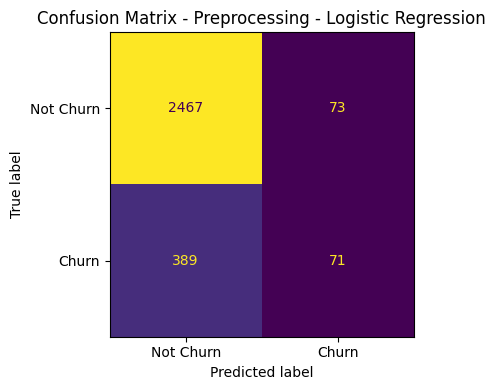

Training model: Random Forest
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      2540
           1       0.48      0.19      0.27       460

    accuracy                           0.84      3000
   macro avg       0.67      0.58      0.59      3000
weighted avg       0.81      0.84      0.81      3000



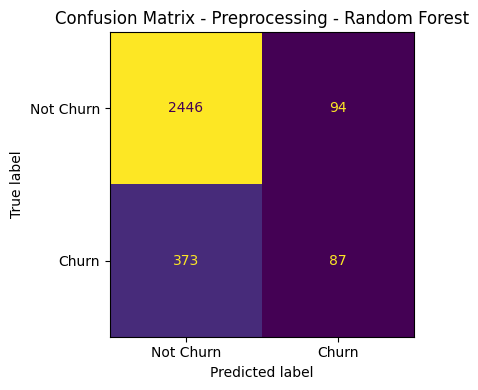

Training model: Voting Classifier
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      2540
           1       0.51      0.20      0.29       460

    accuracy                           0.85      3000
   macro avg       0.69      0.58      0.60      3000
weighted avg       0.81      0.85      0.82      3000



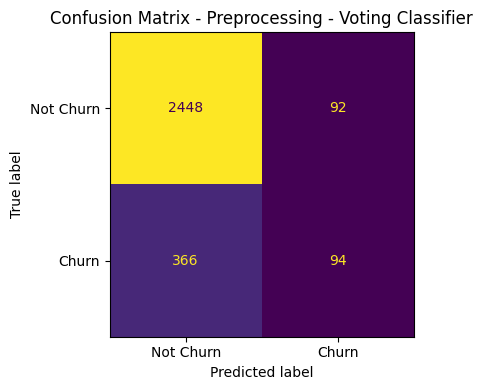

In [25]:
# List untuk menyimpan hasil evaluasi
results = []

# Dictionary untuk menyimpan model yang sudah dilatih
trained_models = {}

for model_name, model in models.items():
    print("=" * 70)
    print(f"Training model: {model_name}")
    
    # Melatih model
    model.fit(X_train_processed_df, y_train)
    
    # Menyimpan model yang sudah dilatih
    trained_models[model_name] = model
    
    # Prediksi data uji
    y_pred = model.predict(X_test_processed_df)
    
    # Menghitung metrik evaluasi
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results.append({
        "Scenario": "Preprocessing",
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Churn", "Churn"]
    )
    disp.plot(ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix - Preprocessing - {model_name}")
    plt.tight_layout()
    
    safe_model_name = model_name.lower().replace(" ", "_")
    plt.savefig(
        FIGURES_DIR / f"confusion_matrix_preprocessing_{safe_model_name}.png",
        dpi=150,
        bbox_inches="tight"
    )
    
    plt.show()

## Hasil Evaluasi Modeling dengan Preprocessing

Hasil evaluasi disusun ke dalam tabel agar lebih mudah dibandingkan dengan hasil direct modeling.

In [26]:
# Membuat dataframe hasil evaluasi
results_df = pd.DataFrame(results)

results_df

,Scenario,Model,Accuracy,Precision,Recall,F1-Score
0,Preprocessing,Logistic Regression,0.846000,0.493056,0.154348,0.235099
1,Preprocessing,Random Forest,0.844333,0.480663,0.189130,0.271451
2,Preprocessing,Voting Classifier,0.847333,0.505376,0.204348,0.291022


In [27]:
# Menyimpan hasil evaluasi preprocessing
results_df.to_csv(REPORTS_DIR / "preprocessing_modeling_results.csv", index=False)

print("Hasil evaluasi preprocessing berhasil disimpan ke:")
print(REPORTS_DIR / "preprocessing_modeling_results.csv")

Hasil evaluasi preprocessing berhasil disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\preprocessing_modeling_results.csv


## Model Terbaik pada Skenario Preprocessing

Model terbaik sementara pada skenario preprocessing dipilih berdasarkan nilai F1-Score tertinggi. F1-Score digunakan karena kasus churn memiliki distribusi target yang tidak seimbang.

In [28]:
# Menentukan model terbaik pada skenario preprocessing berdasarkan F1-Score
best_preprocessing_model = results_df.sort_values(by="F1-Score", ascending=False).iloc[0]

best_preprocessing_model

Scenario         Preprocessing
Model        Voting Classifier
Accuracy              0.847333
Precision             0.505376
Recall                0.204348
F1-Score              0.291022
Name: 2, dtype: object

## Perbandingan dengan Direct Modeling

Jika hasil direct modeling tersedia, hasil preprocessing akan digabungkan dengan hasil direct modeling. Perbandingan ini digunakan untuk melihat apakah preprocessing memberikan perubahan performa terhadap model.

In [29]:
direct_results_path = REPORTS_DIR / "direct_modeling_results.csv"

if direct_results_path.exists():
    direct_results_df = pd.read_csv(direct_results_path)
    
    comparison_df = pd.concat(
        [direct_results_df, results_df],
        ignore_index=True
    )
    
    comparison_df.to_csv(REPORTS_DIR / "model_results_partial.csv", index=False)
    
    print("Perbandingan direct modeling dan preprocessing:")
    display(comparison_df)
    
    print("\nFile perbandingan sementara disimpan ke:")
    print(REPORTS_DIR / "model_results_partial.csv")
else:
    print("File direct_modeling_results.csv belum ditemukan.")
    print("Perbandingan akan dilakukan setelah hasil direct modeling tersedia.")

Perbandingan direct modeling dan preprocessing:


,Scenario,Model,Accuracy,Precision,Recall,F1-Score
0,Direct Modeling,Logistic Regression,0.836000,0.289474,0.047826,0.082090
1,Direct Modeling,Random Forest,0.846667,0.500000,0.008696,0.017094
2,Direct Modeling,Voting Classifier,0.842333,0.465241,0.189130,0.268934
3,Preprocessing,Logistic Regression,0.846000,0.493056,0.154348,0.235099
4,Preprocessing,Random Forest,0.844333,0.480663,0.189130,0.271451
5,Preprocessing,Voting Classifier,0.847333,0.505376,0.204348,0.291022



File perbandingan sementara disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\model_results_partial.csv


## Feature Importance Sementara dari Random Forest

Feature importance digunakan untuk melihat fitur yang dianggap paling berpengaruh oleh Random Forest pada skenario preprocessing. Analisis feature importance yang lebih lengkap akan dilanjutkan pada tahap hyperparameter tuning dan feature selection.

In [30]:
# Mengambil feature importance dari Random Forest
rf_model = trained_models["Random Forest"]

feature_importance_df = pd.DataFrame({
    "feature": X_train_processed_df.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
7,numeric__total_spent,0.183051
13,numeric__satisfaction_score,0.164443
10,numeric__support_tickets,0.065086
15,numeric__marketing_spend_per_user,0.038018
3,numeric__avg_session_time,0.037239
16,numeric__lifetime_value,0.036682
4,numeric__pages_per_session,0.036451
19,numeric__days_since_last_purchase,0.036323
8,numeric__avg_order_value,0.035209
18,numeric__customer_tenure_days,0.034178


In [31]:
# Menyimpan feature importance
feature_importance_df.to_csv(
    REPORTS_DIR / "feature_importance_preprocessing_random_forest.csv",
    index=False
)

print("Feature importance disimpan ke:")
print(REPORTS_DIR / "feature_importance_preprocessing_random_forest.csv")

Feature importance disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\feature_importance_preprocessing_random_forest.csv


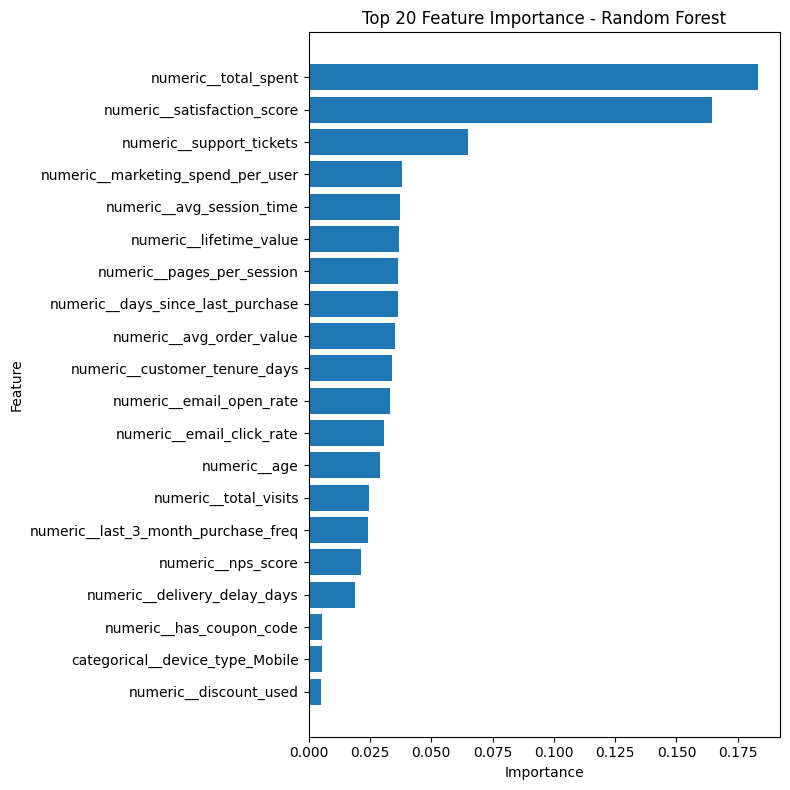

In [32]:
# Visualisasi top 20 feature importance
top_features = feature_importance_df.head(20).sort_values(by="importance")

plt.figure(figsize=(8, 8))
plt.barh(top_features["feature"], top_features["importance"])

plt.title("Top 20 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "feature_importance_preprocessing_random_forest.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Menyimpan Model Skenario Preprocessing

Model terbaik pada skenario preprocessing disimpan sebagai dokumentasi. Model ini belum menjadi model final karena proses hyperparameter tuning belum dilakukan.

In [33]:
# Menyimpan model terbaik pada skenario preprocessing
best_model_name = best_preprocessing_model["Model"]
best_model_object = trained_models[best_model_name]

joblib.dump(best_model_object, MODELS_DIR / "best_preprocessing_model.pkl")

print("Model terbaik pada skenario preprocessing:", best_model_name)
print("Model disimpan ke:")
print(MODELS_DIR / "best_preprocessing_model.pkl")

Model terbaik pada skenario preprocessing: Voting Classifier
Model disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\models\best_preprocessing_model.pkl


## Kesimpulan Modeling dengan Preprocessing

Pada tahap ini, preprocessing sudah dilakukan sebelum model dilatih. Proses preprocessing meliputi feature engineering, penghapusan fitur yang kurang relevan, handling duplikasi, handling missing value, handling outlier, encoding fitur kategorikal, dan scaling fitur numerik.

Tiga model yang digunakan sama seperti tahap direct modeling, yaitu Logistic Regression, Random Forest Classifier, dan Voting Classifier. Hasil evaluasi dari tahap ini akan dibandingkan dengan direct modeling untuk melihat dampak preprocessing terhadap performa model.

Model terbaik pada tahap ini belum menjadi model final. Model final akan ditentukan setelah tahap hyperparameter tuning dan perbandingan seluruh skenario selesai dilakukan.